In [22]:
import torch
import pandas as pd
import networkx as nx
from torch_geometric.data import Data

nodes_df   = pd.read_csv('./pre_processing_output/snare_nonsnare_nodes.csv')
edges_df = pd.read_csv('./pre_processing_output/snare_nonsnare_edges.csv')

nodes_df['GO_embeddings'] = nodes_df['GO_embeddings'].apply(lambda x: torch.tensor(eval(x), dtype=torch.float))
nodes_df['label'] = nodes_df['label'].apply(lambda x: torch.tensor(x, dtype=torch.float))

# Aggiungo nodi al grafo
G = nx.Graph()
for _, row in nodes_df.iterrows():
    num_id = int(row['index'])
    G.add_node(num_id, name=row['STRING_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.float))

edges_df['num_id_1'] = edges_df['num_id_1'].astype(int)
edges_df['num_id_2'] = edges_df['num_id_2'].astype(int)
edges = torch.tensor(edges_df[['num_id_1', 'num_id_2']].values.T, dtype=torch.int)

# Training Data
data = Data(
    x=torch.stack([G.nodes[n]['x'] for n in G.nodes]),  # Features
    edge_index=edges,  # Edges
    y=torch.stack([G.nodes[n]['y'] for n in G.nodes]),
)

data


/tmp/ipykernel_7764/3251928579.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  G.add_node(num_id, name=row['STRING_id'], x=row['GO_embeddings'], y=torch.tensor(row['label'], dtype=torch.float))


Data(x=[74, 200], edge_index=[2, 288], y=[74])

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import numpy as np
import torch.optim as optim
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, dropout=0):
        super(GCN, self).__init__()
        
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        # self.conv3 = GCNConv(hidden_channels, out_channels)

        self.dropout = dropout
    
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.sigmoid(x)      
        x = F.dropout(x, p=self.dropout, training=self.training)

        '''
        x = self.conv2(x, edge_index)
        x = F.sigmoid(x)
        x = F.dropout(x, p=self.dropout, training=self.training)'''
        
        x = self.conv2(x, edge_index)
        return x.view(-1)  # Output logits
    
    def train_model(self, data, optimizer, criterion, epochs=200, patience=10, log=True):
        self.train()
        loss_values = []
        val_loss_values = []
        best_val_loss = float('inf')
        patience_counter = 0

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

        for epoch in range(epochs):
            optimizer.zero_grad()
            out = self.forward(data.x, data.edge_index)
            train_loss = criterion(out[data.train_mask], data.y[data.train_mask].float())
            train_loss.backward()
            optimizer.step()

            self.eval()
            with torch.no_grad():
                val_out = self.forward(data.x, data.edge_index)
                val_loss = criterion(val_out[data.val_mask], data.y[data.val_mask].float())
            self.train()

            loss_values.append(train_loss.item())
            val_loss_values.append(val_loss.item())

            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered at epoch {epoch}")
                    break

            if epoch % 10 == 0 and log:
                print(f"Epoch {epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        if log:
            plt.figure()
            plt.plot(range(len(loss_values)), loss_values, label='Training Loss')
            plt.plot(range(len(val_loss_values)), val_loss_values, label='Validation Loss', linestyle='dashed')
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.title('Training & Validation Loss Curve')
            plt.legend()
            plt.show()
    
    def k_fold_cross_validation(self, data, k=5, epochs=50, learning_rate=0.001, patience=10, log=True):
        """
        Questa funzione imposta un k-fold cross validation stratificato assicurandosi di avere le proteine
        in comune sempre nel test set (sarebbe un data leakage altrimenti).
        Esegue i k training e stampa le metriche di valutazione, la media di queste ed il miglior modello allenato.
        """
        kf = StratifiedKFold(n_splits=k, shuffle=True)
        indices = np.arange(data.x.shape[0])
        best_model = None
        best_f1 = 0
        acc_scores, precision_scores, recall_scores, f1_scores = [], [], [], []
        best_fold_metrics = {}
        best_cm = None

        for fold, (train_idx, val_idx) in enumerate(kf.split(data.x, data.y.cpu().numpy())):          
            if log: 
                print(f"\n🔹 Fold {fold+1}/{k}")
            train_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
            val_mask = torch.zeros(data.x.shape[0], dtype=torch.bool)
            
            # Aggiungi le proteine comuni al training set
            train_mask[train_idx] = True
            val_mask[val_idx] = True
            
            data.train_mask = train_mask
            data.val_mask = val_mask
            data.test_mask = ~train_mask

            model = GCN(in_channels=self.conv1.in_channels, 
                        hidden_channels=self.conv1.out_channels, 
                        out_channels=self.conv2.out_channels, 
                        dropout=self.dropout)
            optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=5e-4)
            criterion = torch.nn.BCEWithLogitsLoss()
            model.train_model(data, optimizer, criterion, epochs, patience, log=log)

            model.eval()
            with torch.no_grad():
                out = model(data.x, data.edge_index)
                out = torch.sigmoid(out)
                pred = (out[val_mask] > 0.5).int()
                y_true = data.y[val_mask].cpu().numpy()
                y_pred = pred.cpu().numpy()

                acc = accuracy_score(y_true, y_pred)
                precision = precision_score(y_true, y_pred)
                recall = recall_score(y_true, y_pred)
                f1 = f1_score(y_true, y_pred)
                cm = confusion_matrix(y_true, y_pred)

                acc_scores.append(acc)
                precision_scores.append(precision)
                recall_scores.append(recall)
                f1_scores.append(f1)

                if log:
                    print(f"Accuracy: {acc:.4f}")
                    print(f"Precision: {precision:.4f}")
                    print(f"Recall: {recall:.4f}")
                    print(f"F1-Score: {f1:.4f}")

                if f1 > best_f1:
                    best_f1 = f1
                    best_model = model
                    best_fold_metrics = {
                        "Accuracy": acc,
                        "Precision": precision,
                        "Recall": recall,
                        "F1-Score": f1,
                        "training_fold": train_idx,
                        "val_fold": val_idx
                    }
                    best_cm = cm

        if log:
            print("\n📊 **Statistiche medie della K-Fold Cross Validation**")
            print(f"Accuracy: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
            print(f"Precision: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
            print(f"Recall: {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
            print(f"F1-Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

            if best_cm is not None:
                plt.figure(figsize=(6,6))
                sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
                plt.xlabel("Predicted")
                plt.ylabel("Actual")
                plt.title("Confusion Matrix of Best Model")
                plt.show()
        
        return best_model, best_fold_metrics



🔹 Fold 1/5
Epoch 0, Train Loss: 0.8089, Val Loss: 0.6957, LR: 0.001000


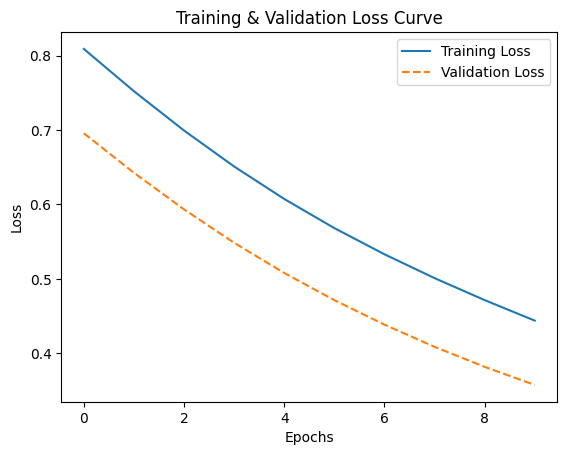

Accuracy: 0.9333
Precision: 0.8889
Recall: 1.0000
F1-Score: 0.9412

🔹 Fold 2/5
Epoch 0, Train Loss: 0.7773, Val Loss: 0.7416, LR: 0.001000


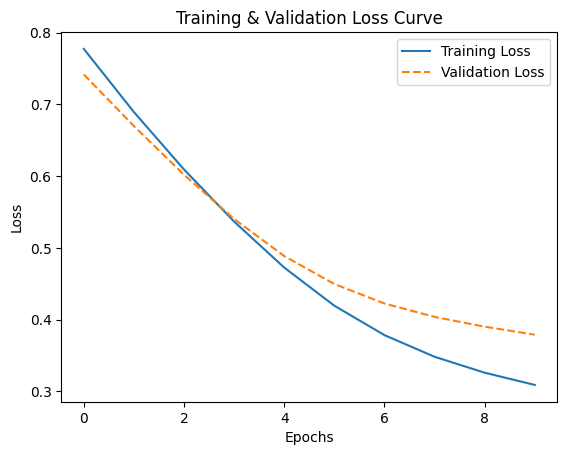

Accuracy: 0.8667
Precision: 0.8000
Recall: 1.0000
F1-Score: 0.8889

🔹 Fold 3/5
Epoch 0, Train Loss: 0.6991, Val Loss: 0.6394, LR: 0.001000


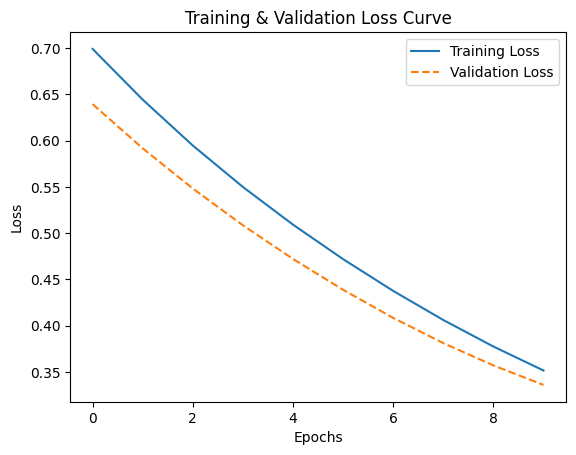

Accuracy: 0.9333
Precision: 0.8750
Recall: 1.0000
F1-Score: 0.9333

🔹 Fold 4/5
Epoch 0, Train Loss: 0.5875, Val Loss: 0.5966, LR: 0.001000


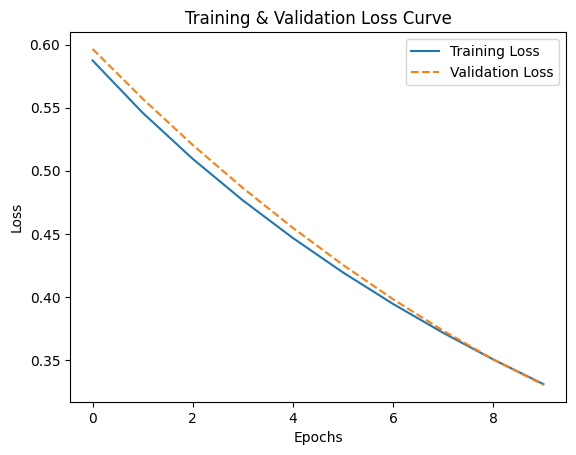

Accuracy: 0.8667
Precision: 0.7778
Recall: 1.0000
F1-Score: 0.8750

🔹 Fold 5/5
Epoch 0, Train Loss: 0.7244, Val Loss: 0.6457, LR: 0.001000


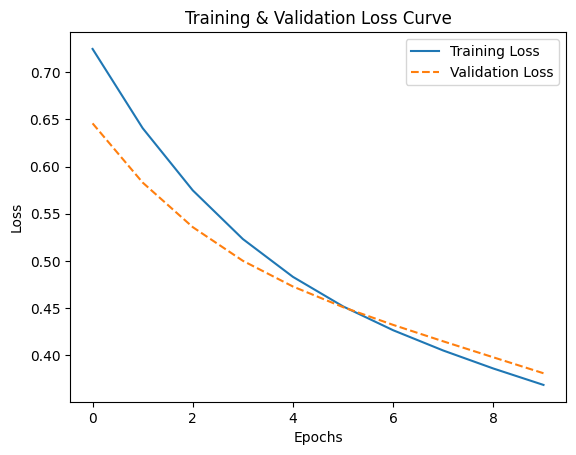

Accuracy: 0.8571
Precision: 0.7778
Recall: 1.0000
F1-Score: 0.8750

📊 **Statistiche medie della K-Fold Cross Validation**
Accuracy: 0.8914 ± 0.0344
Precision: 0.8239 ± 0.0483
Recall: 1.0000 ± 0.0000
F1-Score: 0.9027 ± 0.0288


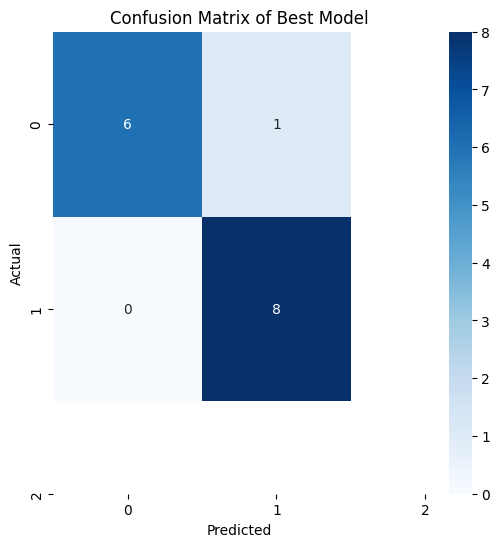


🧪 **Valutazione sul test set finale (10%)**
Accuracy: 0.9286
Precision: 0.8750
Recall: 1.0000
F1-score: 0.9333


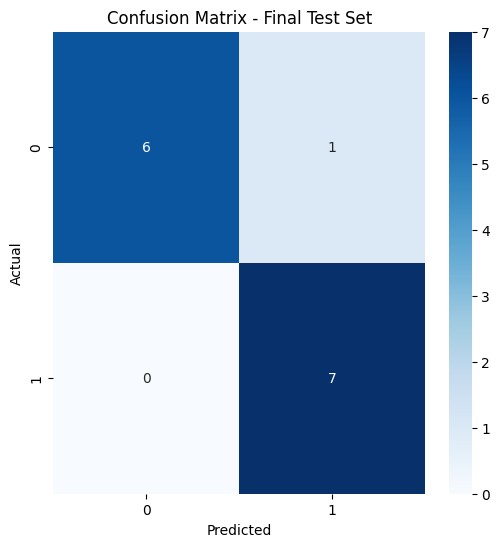

In [24]:
from torch.optim import Adam

LR = 0.001

model = GCN(in_channels=data.x.shape[1], hidden_channels=32, out_channels=1, dropout=0)
optimizer = Adam(model.parameters(), lr=LR, weight_decay=5e-4)
best_model, best_metrics = model.k_fold_cross_validation(data, k=5, epochs=10, learning_rate=LR, patience=10, log=True)

# Testing su dataset precedentemente estratto
best_model.eval()
with torch.no_grad():
    out = best_model(data.x, data.edge_index)
    out = torch.sigmoid(out)

    pred = (out[data.test_mask] > 0.5).int()
    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = pred.cpu().numpy()

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print("\n🧪 **Valutazione sul test set finale (10%)**")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - Final Test Set")
    plt.show()